# Figure 5: Mixed vs. Blocked SNR

Translation of `Figure05_mixedVsBlockedSNR.m`

## What this notebook does

Compares how participants' decision bounds relate to SNR in two task variants:

- **OL (Blocked SNR)**: Each block contains only one SNR level; subjects know which SNR applies.
- **MX (Mixed SNR)**: Multiple SNR levels are interleaved within a block; subjects must infer the SNR.

The hypothesis: in mixed SNR, subjects cannot set SNR-specific bounds, so low-SNR and high-SNR
bounds should be more similar than in blocked SNR.

**Figure** — 2 rows (OL / MX) × 3 columns (blocks 1–3):
Reward-rate heatmap (coins per trial vs. lo × hi SNR bound pair), with per-subject mean bounds
overlaid as open circles. The optimal point is marked with a red cross; the near-optimal region
(≥ 95 % of max RR) with black crosses. Wilcoxon signed-rank test (lo vs. hi bound per subject)
reported in the panel title.

**Data**: Blocks 1–3, pre-filtered to `DT > 2` (keeps DT ≥ 3), all subjects.

## Imports

Standard scientific Python libraries plus `get_data_table`, `get_bound_summary`, and
`get_simulated_data_table`. No data loading or analysis here.

## Load data

Loads both task variants:
- `data_table_mx`: Mixed-SNR (MX) task — multiple SNR levels interleaved within each block.
- `data_table_ol`: Online / Blocked-SNR (OL) task — one SNR level per block.

Both calls apply internal processing: bound/DT computation, wall-hit marking, bias correction,
and block merging (6 → 3 blocks). No trials are dropped at this stage.

## Parameters and RR-matrix computation

**`MIN_DT`**: Pre-filter applied before `get_bound_summary`; keeps DT ≥ 3 (matching MATLAB `minDT=2`).

**`BLOCKS`**: All three blocks analysed: block 1 (gain only), block 2 (coin penalty for errors),
block 3 (step loss for errors).

**`RR_BOUNDS`**: Bound grid for the reward-rate simulation (0.01 to 0.76 in steps of 0.05, 16
values — matching MATLAB `rrBounds = 0.01:0.05:0.76`).

**`NUM_RR_REPS`**: Number of simulated subjects per condition (matching MATLAB `numRRReps=100`).

**`G_MEANS`**: Generative means for lo and hi SNR (matching MATLAB defaults `[0.05 0.15]`).

**`COMPUTE_RR`**: Set to `False` to skip the slow simulation and show only the scatter overlay.
The simulation takes ~1 min per block for OL and ~15 min per block for MX.

**`rr_matrices`**: Dict keyed by `(task_type, block)`. Both OL and MX are stored as
`rr_matrix[hi_idx, lo_idx]` so `imshow(origin='lower')` places lo-SNR bound on the x-axis and
hi-SNR bound on the y-axis, matching the scatter overlay and axis labels.

**`get_bound_summary` internal filters** (via `get_good_trial_array`):
`DT ≥ 2`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`.

**Data included**: All subjects, each block separately, all SNR levels (sorted ascending:
index 0 = lo SNR, index −1 = hi SNR).

**Data excluded**: Subjects with fewer than 2 valid SNR levels (panel skipped).

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.simulate import get_simulated_data_table
from pigeon.pathDefaults import FIGURES_DIR

In [7]:
data_table_mx = get_data_table(task_type='MX')
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_09h13.45.625.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h11.56.537.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h12.28.806.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.05.149.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.09.605.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.30.507.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_MX/prolificcsvs/PigeonTask_2022-11-23_10h13.32.506.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [8]:
# ── Parameters ────────────────────────────────────────────────────────────────
MIN_DT      = 2                             # keep DT > MIN_DT (i.e. DT ≥ 3)
BLOCKS      = [1, 2, 3]                     # all three task blocks
RR_BOUNDS   = np.arange(0.01, 0.81, 0.05)  # bound grid: 0.01:0.05:0.76 (16 values)
NUM_RR_REPS = 100                           # simulated subjects per RR computation
G_MEANS     = [0.05, 0.15]                 # lo and hi SNR generative means
COMPUTE_RR  = True                          # False = skip slow simulation

BLOCK_LABELS = {1: 'block 1', 2: 'block 2', 3: 'block 3'}

rng = np.random.default_rng(42)


# ── Helper: simulate reward-rate matrix ───────────────────────────────────────
def compute_rr_matrix(task_type, block, rr_bounds, num_reps, g_means, rng):
    """Compute expected reward rate over a lo-SNR-bound × hi-SNR-bound grid.

    Both OL and MX return rr_matrix[hi_idx, lo_idx] so that imshow(origin='lower')
    displays the matrix with lo-SNR bound on the x-axis and hi-SNR bound on the
    y-axis, matching the scatter overlay and axis labels.

    For OL (blocked SNR): lo and hi SNR blocks are simulated separately for each
    bound value. Their mean coin counts are added, matching MATLAB's accumulation:
        RRMatrix_(:, b1) += mean(loCoinCounts)   [column b1 = lo-bound]
        RRMatrix_(b1, :) += mean(hiCoinCounts)   [row b1 = hi-bound]
    → rr_matrix[hi_idx, lo_idx]

    For MX (mixed SNR): each (lo_bound, hi_bound) pair requires its own
    simulation with both SNR levels interleaved (equivalent to MATLAB's
    boundType='varBySNR'). Stored as rr_matrix[hi_idx, lo_idx] to match OL.
    """
    n = len(rr_bounds)
    rr_matrix = np.zeros((n, n))
    specs = {'num_subjects': num_reps, 'blocks': [block]}

    if task_type == 'OL':
        for b1, bnd in enumerate(rr_bounds):
            print(f'  OL block {block} RR matrix: bound {b1 + 1}/{n}', end='\r')

            lo_table = get_simulated_data_table(
                specs=specs, generative_mean=g_means[0],
                bound_mean=bnd, correct_bias=None, rng=rng)
            lo_coins = lo_table.groupby('subject_index')['coin_count'].last().mean()

            hi_table = get_simulated_data_table(
                specs=specs, generative_mean=g_means[1],
                bound_mean=bnd, correct_bias=None, rng=rng)
            hi_coins = hi_table.groupby('subject_index')['coin_count'].last().mean()

            rr_matrix[:, b1] += lo_coins
            rr_matrix[b1, :] += hi_coins

    else:  # MX — stored as rr_matrix[hi_idx, lo_idx] to match OL display convention
        for b1, lo_bnd in enumerate(rr_bounds):
            print(f'  MX block {block} RR matrix: lo-bound {b1 + 1}/{n}', end='\r')
            for b2, hi_bnd in enumerate(rr_bounds):
                mx_table = get_simulated_data_table(
                    specs=specs,
                    generative_mean=list(g_means),
                    bound_mean=[lo_bnd, hi_bnd],
                    correct_bias=None, rng=rng)
                rr_matrix[b2, b1] = (
                    mx_table.groupby('subject_index')['coin_count'].last().mean())
    print()
    return rr_matrix


# ── Helper: heatmap + scatter panel ───────────────────────────────────────────
def _plot_heatmap_panel(ax, data_table, block, min_dt, rr_bounds, rr_matrix):
    """Lo × hi SNR bound heatmap with subject scatter.  Returns Wilcoxon p or None."""
    this_table = data_table[data_table['DT'] > min_dt].reset_index(drop=True)
    bs_all = get_bound_summary(this_table, blocks=[block], max_rt='all')

    if bs_all.shape[2] < 2:
        ax.axis('off')
        return None

    lo = bs_all[:, 0,  0, 0, 0]   # mean abs bound, lo SNR, all DTs collapsed
    hi = bs_all[:, 0, -1, 0, 0]   # mean abs bound, hi SNR, all DTs collapsed

    b_min, b_max = rr_bounds[0], rr_bounds[-1]

    if rr_matrix is not None:
        ax.imshow(
            rr_matrix, origin='lower',
            extent=[b_min - 0.025, b_max + 0.025, b_min - 0.025, b_max + 0.025],
            aspect='auto', vmin=0, vmax=rr_matrix.max(), cmap='viridis')

        near_opt = rr_matrix >= 0.95 * rr_matrix.max()
        hi_idxs, lo_idxs = np.where(near_opt)
        ax.plot(rr_bounds[lo_idxs], rr_bounds[hi_idxs], 'kx', markersize=4)

        opt_hi, opt_lo = np.unravel_index(rr_matrix.argmax(), rr_matrix.shape)
        ax.plot(rr_bounds[opt_lo], rr_bounds[opt_hi], 'rx',
                markersize=10, markeredgewidth=2)

    ax.plot([0, 0.75], [0, 0.75], 'k:', linewidth=1)

    valid = np.isfinite(lo) & np.isfinite(hi)
    ax.plot(lo[valid], hi[valid], 'ko', markerfacecolor='white',
            markersize=8, markeredgewidth=1.5)
    ax.set_xlim(0, 0.75)
    ax.set_ylim(0, 0.75)
    ax.set_aspect('equal')

    if valid.sum() > 2:
        _, p = scipy.stats.wilcoxon(lo[valid], hi[valid])
        return p
    return None


# ── Task list ─────────────────────────────────────────────────────────────────
tasks = [
    (data_table_ol, 'OL (Blocked SNR)', 'OL'),
    (data_table_mx, 'MX (Mixed SNR)',   'MX'),
]

# ── Compute RR matrices: keyed by (task_type, block) ─────────────────────────
rr_matrices = {}

if COMPUTE_RR:
    for _, label, task_type in tasks:
        for block in BLOCKS:
            print(f'Computing RR matrix for {task_type} block {block}...')
            rr_matrices[(task_type, block)] = compute_rr_matrix(
                task_type, block, RR_BOUNDS, NUM_RR_REPS, G_MEANS, rng)
            print(f'  Done.')

Computing RR matrix for OL block 1...
  OL block 1 RR matrix: bound 16/16
  Done.
Computing RR matrix for OL block 2...
  OL block 2 RR matrix: bound 16/16
  Done.
Computing RR matrix for OL block 3...
  OL block 3 RR matrix: bound 16/16
  Done.
Computing RR matrix for MX block 1...
  MX block 1 RR matrix: lo-bound 16/16
  Done.
Computing RR matrix for MX block 2...
  MX block 2 RR matrix: lo-bound 16/16
  Done.
Computing RR matrix for MX block 3...
  MX block 3 RR matrix: lo-bound 16/16
  Done.


## Figure

Publication-quality figure at 14 cm wide (≈ 2.4 JNeurosci columns): 2 rows (OL / MX) × 3 columns
(blocks 1–3) of heatmap + scatter panels. Panel width = height = 4 cm; gaps 1.0 cm (horizontal)
× 1.3 cm (vertical). Block label in column header (top row); Wilcoxon p in each panel title;
task-type row label on the left y-axis. Saves to `Figure05.pdf`.

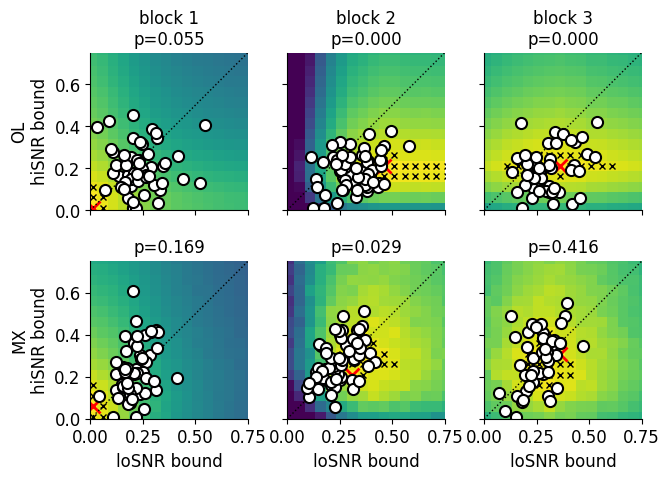

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure05_formatted.pdf


In [ ]:
# ── Main figure: 2 rows (OL/MX) × 3 cols (blocks 1–3), heatmap panels ────────
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 14.0           # figure width (cm)
HTS = [4.0, 4.0]     # row heights (cm) — matches panel width for square axes
PSH = 1.3            # vertical panel separation (cm)
PSW = 1.0            # horizontal panel separation (cm)
FS  = 12             # font size (pt)

n_rows  = len(tasks)
n_cols  = len(BLOCKS)
fig_h   = sum(HTS) + PSH * (n_rows - 1)
panel_w = (WID - PSW * (n_cols - 1)) / n_cols  # = 4.0 cm → square panels

hspace = PSH / np.mean(HTS)
wspace = PSW / panel_w

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

fig_main = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig_main,
                       left=0, right=1, bottom=0, top=1,
                       hspace=hspace, wspace=wspace)
axs = np.array([[fig_main.add_subplot(gs[r, c])
                 for c in range(n_cols)] for r in range(n_rows)])

for row_idx, (data_table, task_label, task_type) in enumerate(tasks):
    for col_idx, block in enumerate(BLOCKS):
        ax = axs[row_idx, col_idx]
        p = _plot_heatmap_panel(
            ax, data_table, block, MIN_DT, RR_BOUNDS,
            rr_matrices.get((task_type, block)))

        # Column label (top row only) + Wilcoxon p
        p_str = f'p={p:.3f}' if p is not None else ''
        title = (BLOCK_LABELS[block] + '\n' if row_idx == 0 else '') + p_str
        ax.set_title(title)

        # y-axis: row label + unit on leftmost column
        if col_idx == 0:
            ax.set_ylabel(f'{task_type}\nhiSNR bound')
        else:
            ax.tick_params(axis='y', labelleft=False)

        # x-axis on bottom row only
        if row_idx == n_rows - 1:
            ax.set_xlabel('loSNR bound')
        else:
            ax.tick_params(axis='x', labelbottom=False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure05.pdf'
fig_main.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## Hi/Lo SNR bound ratio summary

For each condition and block, prints two statistics about the ratio of the high-SNR to low-SNR bound:

1. **Per-participant median [IQR]**: the ratio `hi_bound / lo_bound` computed per subject (using
   the same all-DT-collapsed mean bounds as the heatmap scatter), summarised as
   median [25th–75th percentile] across subjects.
2. **Ratio at the optimal reward rate**: `rr_bounds[opt_hi_idx] / rr_bounds[opt_lo_idx]`, where
   the optimal index is the argmax of the simulated RR matrix.  Requires `COMPUTE_RR = True`.

Both OL and MX matrices are stored as `rr_matrix[hi_idx, lo_idx]`, so `argmax` → `(hi_idx, lo_idx)`
for both.

In [10]:
# ── Hi/Lo SNR bound ratio: per-participant and at optimal RR ──────────────────
print('Ratio of Hi-SNR to Lo-SNR bound\n')

for data_table, label, task_type in tasks:
    print(f'{label}:')
    for block in BLOCKS:
        this_table = data_table[data_table['DT'] > MIN_DT].reset_index(drop=True)
        bs_all = get_bound_summary(this_table, blocks=[block], max_rt='all')

        if bs_all.shape[2] < 2:
            print(f'  Block {block}: insufficient SNR levels')
            continue

        lo = bs_all[:, 0,  0, 0, 0]
        hi = bs_all[:, 0, -1, 0, 0]

        valid = np.isfinite(lo) & np.isfinite(hi) & (lo > 0)
        ratio = hi[valid] / lo[valid]

        med      = np.median(ratio)
        q25, q75 = np.percentile(ratio, [25, 75])

        rr_key = (task_type, block)
        if rr_key in rr_matrices:
            rm = rr_matrices[rr_key]
            opt_hi_idx, opt_lo_idx = np.unravel_index(rm.argmax(), rm.shape)
            opt_lo = RR_BOUNDS[opt_lo_idx]
            opt_hi = RR_BOUNDS[opt_hi_idx]
            rr_str = f'{opt_hi / opt_lo:.3f}  (lo={opt_lo:.2f}, hi={opt_hi:.2f})'
        else:
            rr_str = 'not available (COMPUTE_RR=False)'

        print(f'  Block {block}:  median [IQR] = {med:.3f} [{q25:.3f}, {q75:.3f}];'
              f'  optimal RR ratio = {rr_str}')
    print()

Ratio of Hi-SNR to Lo-SNR bound

OL (Blocked SNR):
  Block 1:  median [IQR] = 0.781 [0.586, 1.286];  optimal RR ratio = 1.000  (lo=0.01, hi=0.01)
  Block 2:  median [IQR] = 0.544 [0.398, 0.779];  optimal RR ratio = 0.457  (lo=0.46, hi=0.21)
  Block 3:  median [IQR] = 0.639 [0.400, 0.826];  optimal RR ratio = 0.583  (lo=0.36, hi=0.21)

MX (Mixed SNR):
  Block 1:  median [IQR] = 1.079 [0.750, 1.445];  optimal RR ratio = 6.000  (lo=0.01, hi=0.06)
  Block 2:  median [IQR] = 1.127 [0.879, 1.442];  optimal RR ratio = 0.677  (lo=0.31, hi=0.21)
  Block 3:  median [IQR] = 1.048 [0.742, 1.345];  optimal RR ratio = 0.861  (lo=0.36, hi=0.31)

